In [3]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("../Data/raw/Crop_recommendation.csv")

In [8]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [9]:

df.shape

(2200, 8)

In [10]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [11]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [12]:
df.sample(10)

,N,P,K,temperature,humidity,ph,rainfall,label
1038,99,73,53,26.290390,81.060038,5.871702,118.673037,banana
1013,106,85,53,27.199460,78.808607,5.915055,99.724308,banana
232,32,60,83,19.691417,19.442254,8.829273,91.760716,chickpea
573,26,51,25,28.764890,52.627415,7.792508,55.216067,mothbeans
283,53,73,77,19.713597,18.096657,7.325451,73.644765,chickpea
530,22,44,24,24.309351,56.329383,6.030447,58.995363,mothbeans
291,42,67,77,18.994244,15.936294,7.114405,78.697072,chickpea
570,23,58,19,24.170932,58.252046,5.243635,59.189534,mothbeans
2131,118,21,34,24.385346,64.725431,7.234258,119.632411,coffee
1915,131,35,18,24.491126,82.244158,7.057693,64.029494,cotton


In [13]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

In [14]:
df.info

<bound method DataFrame.info of         N   P   K  temperature   humidity        ph    rainfall   label
0      90  42  43    20.879744  82.002744  6.502985  202.935536    rice
1      85  58  41    21.770462  80.319644  7.038096  226.655537    rice
2      60  55  44    23.004459  82.320763  7.840207  263.964248    rice
3      74  35  40    26.491096  80.158363  6.980401  242.864034    rice
4      78  42  42    20.130175  81.604873  7.628473  262.717340    rice
...   ...  ..  ..          ...        ...       ...         ...     ...
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

[2200 rows x 8 columns]>

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [16]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

In [20]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.label.unique()

<StringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [23]:
df.label.nunique()

22

In [24]:
df.label.value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## Univariate_Analysis

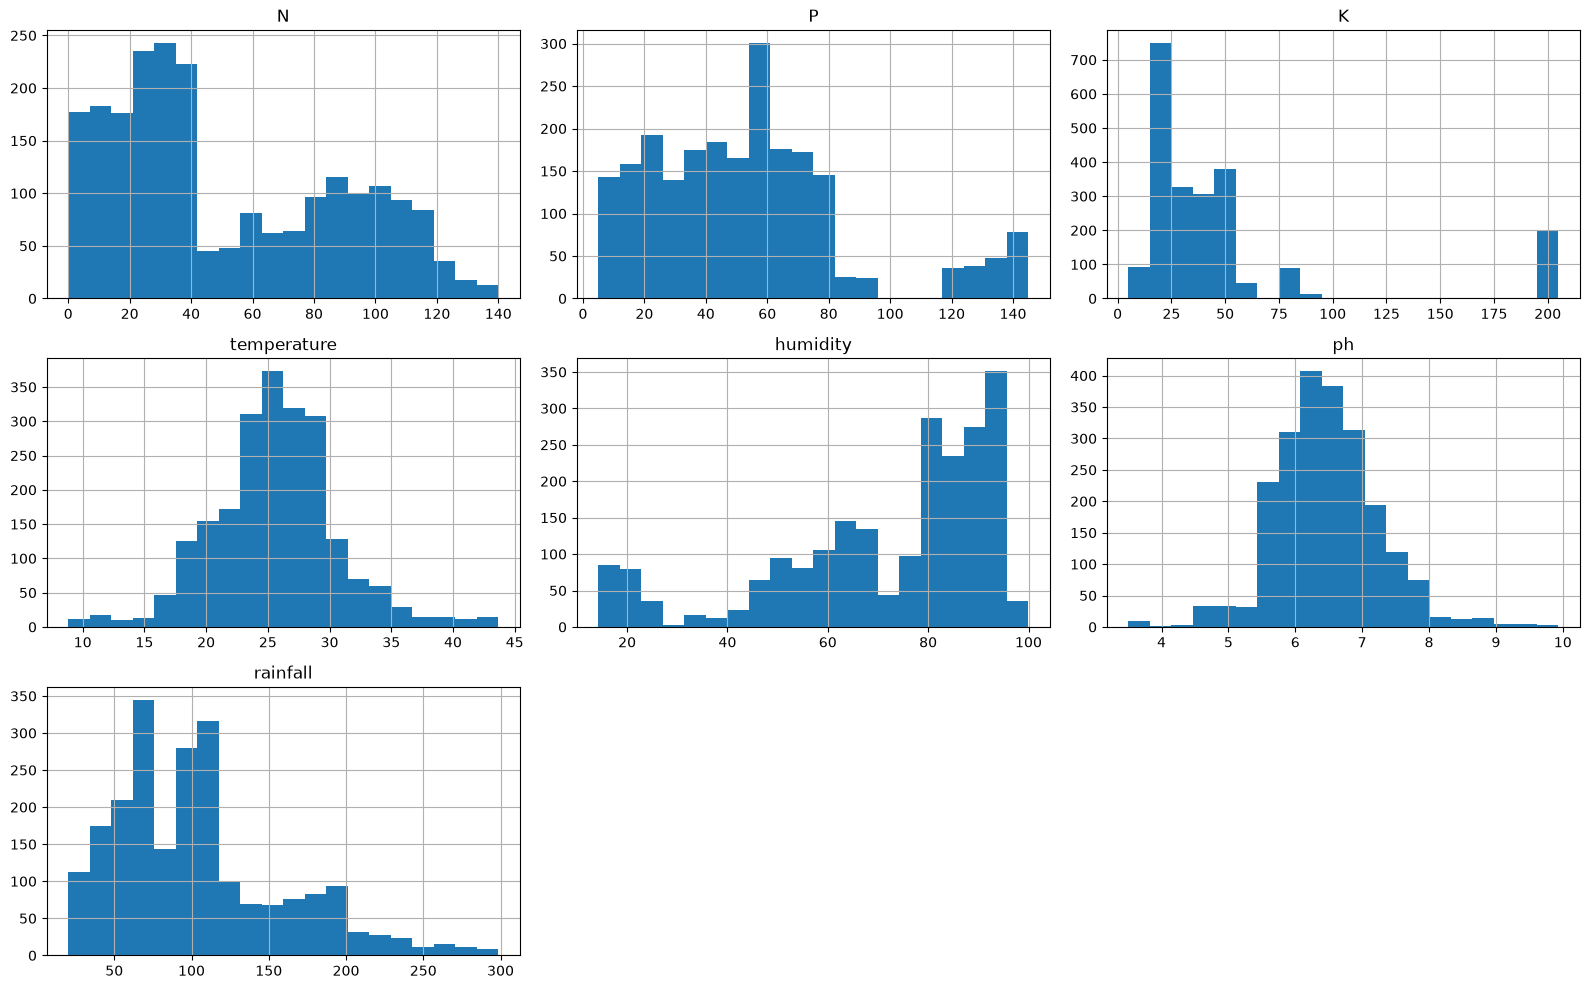

In [25]:
df.hist(figsize=(16,10), bins=20)
plt.tight_layout()
plt.show()

### Distribution Plots

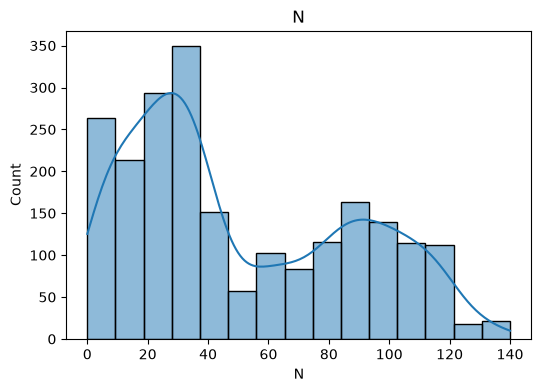

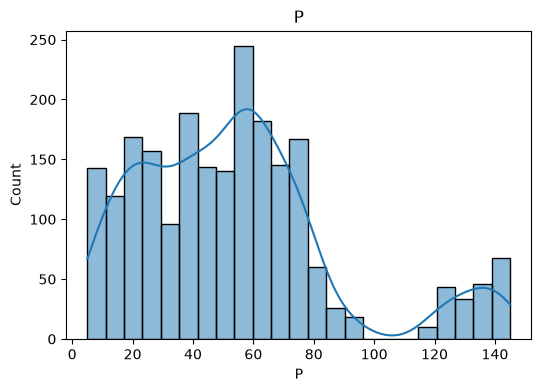

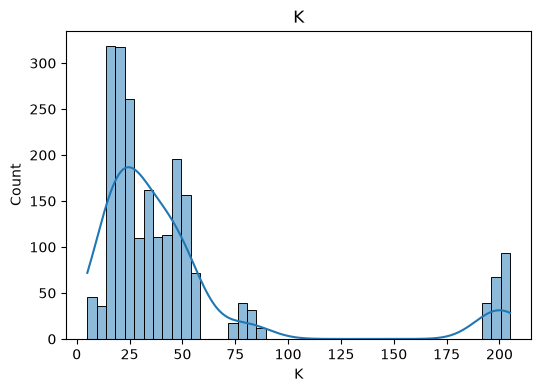

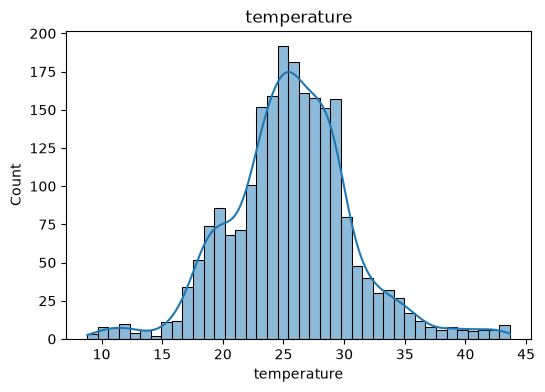

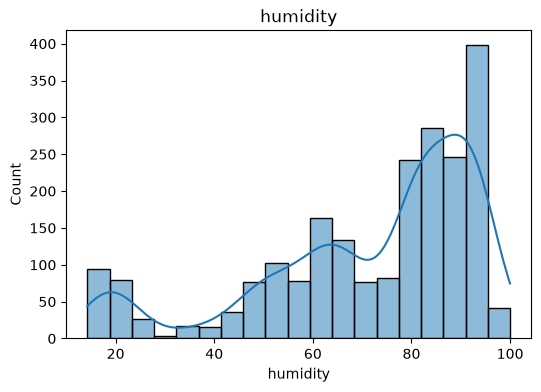

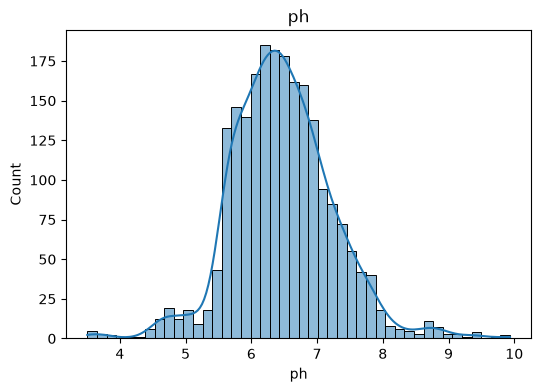

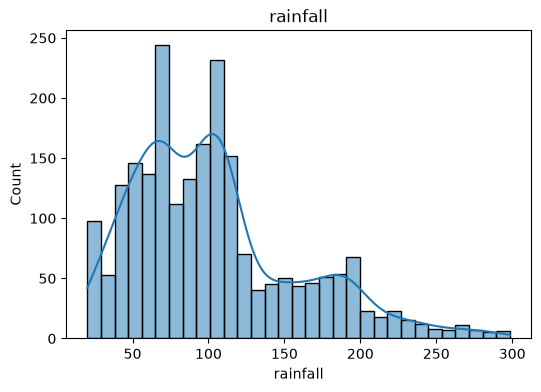

In [26]:
for column in df.columns[:-1]:

    plt.figure(figsize=(6,4))

    sns.histplot(df[column], kde=True)

    plt.title(column)

    plt.show()

## BoxPlots

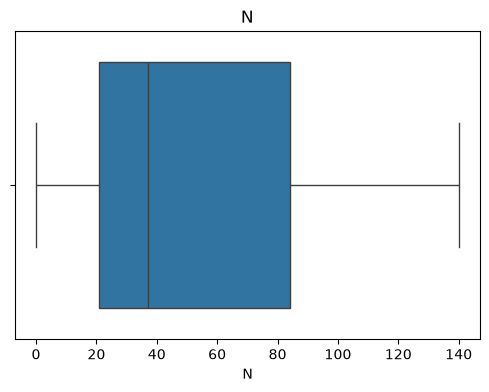

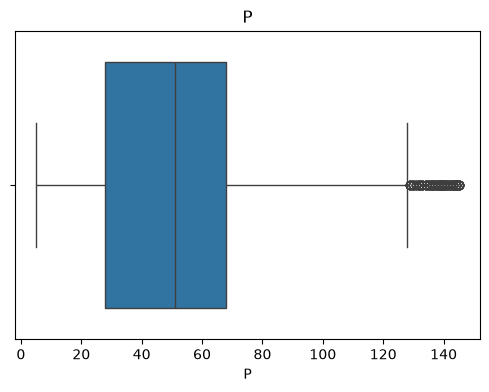

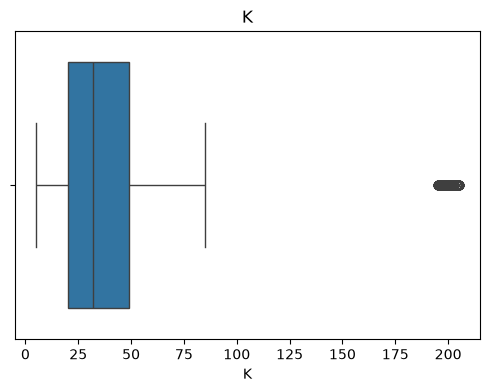

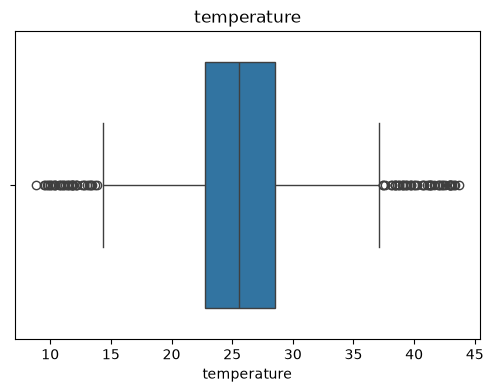

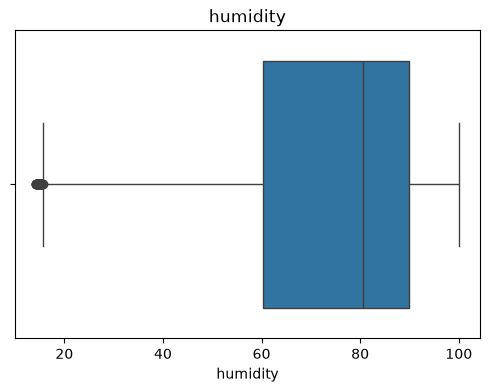

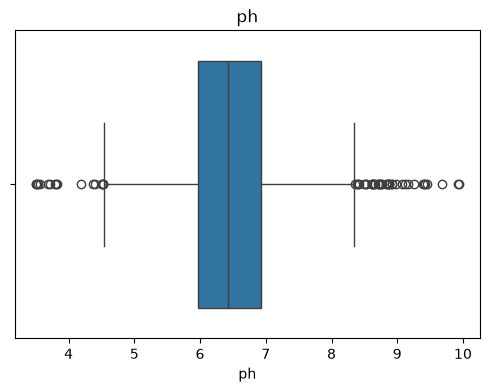

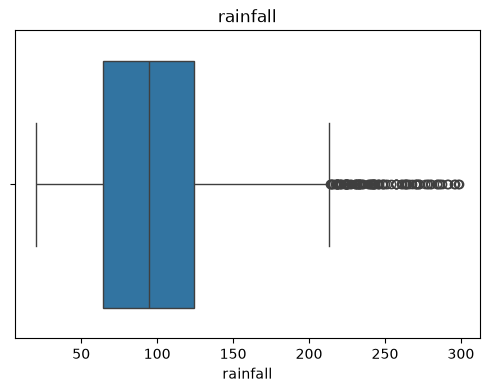

In [27]:
for column in df.columns[:-1]:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

### crop distribution


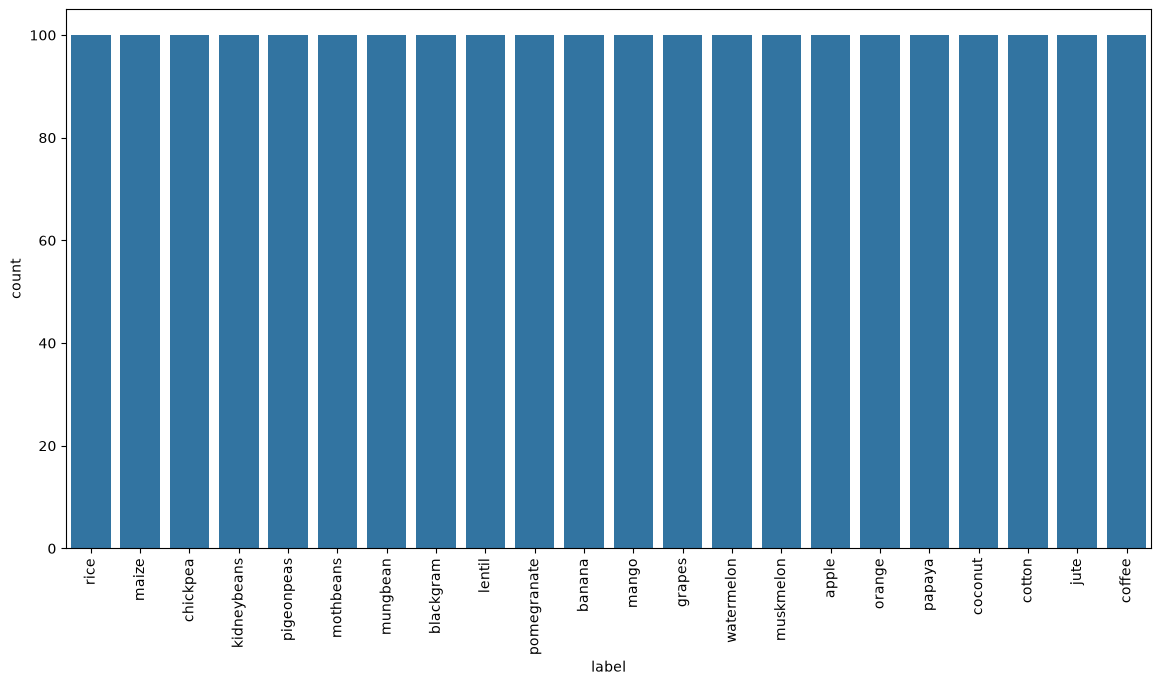

In [28]:
plt.figure(figsize=(14,7))

sns.countplot(data=df,x="label")

plt.xticks(rotation=90)

plt.show()

# correlation matrix

In [29]:
corr=df.corr(numeric_only=True)

corr

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


# heat map

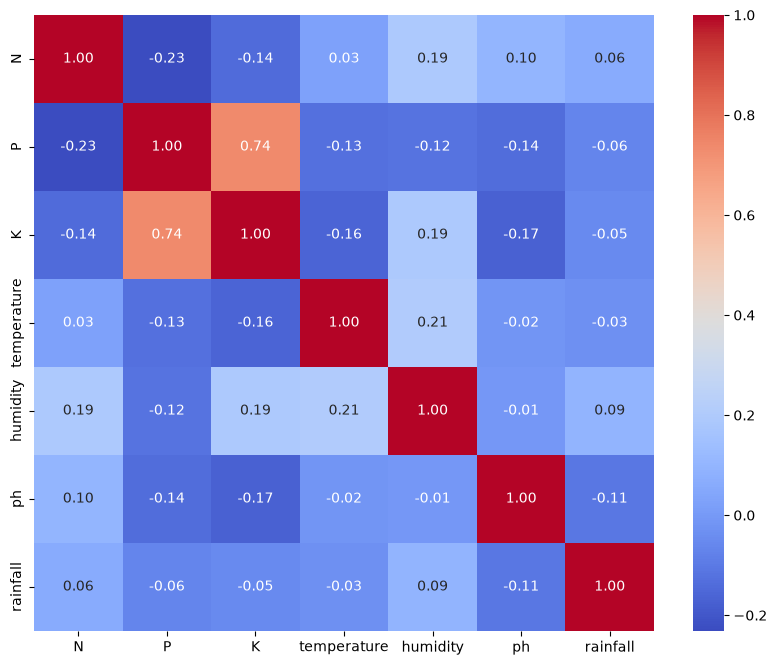

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.show()

# Temperature vs Crop

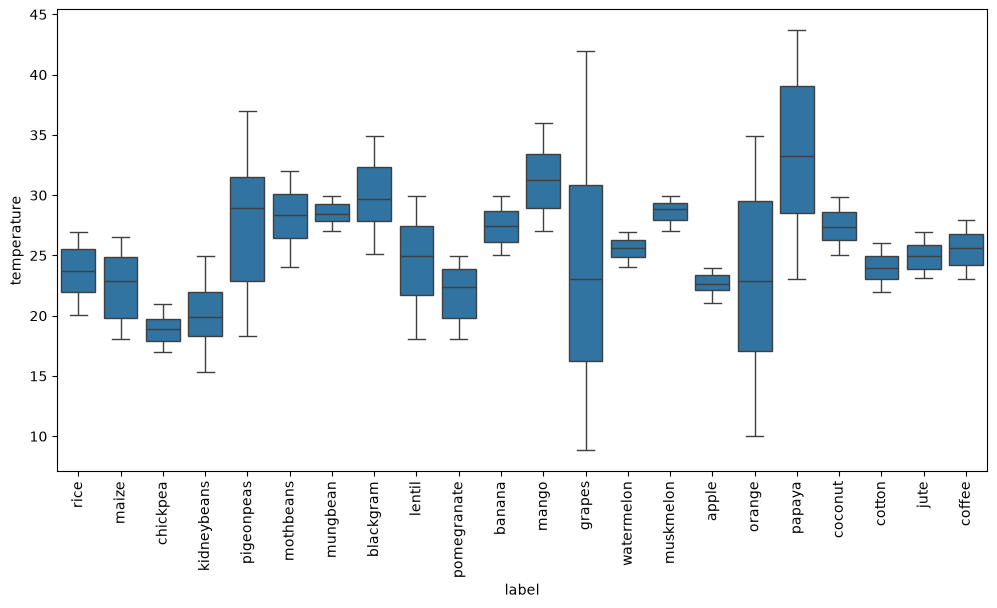

In [31]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x="label",
            y="temperature")

plt.xticks(rotation=90)

plt.show()

# Humidity vs Crop

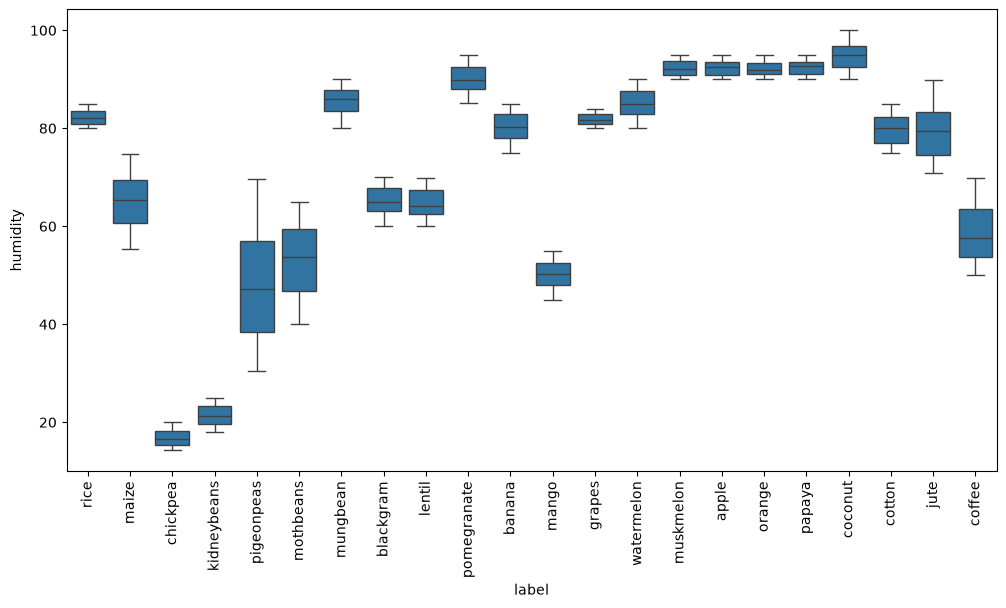

In [32]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x="label",
            y="humidity")

plt.xticks(rotation=90)

plt.show()

# Rainfall vs Crop

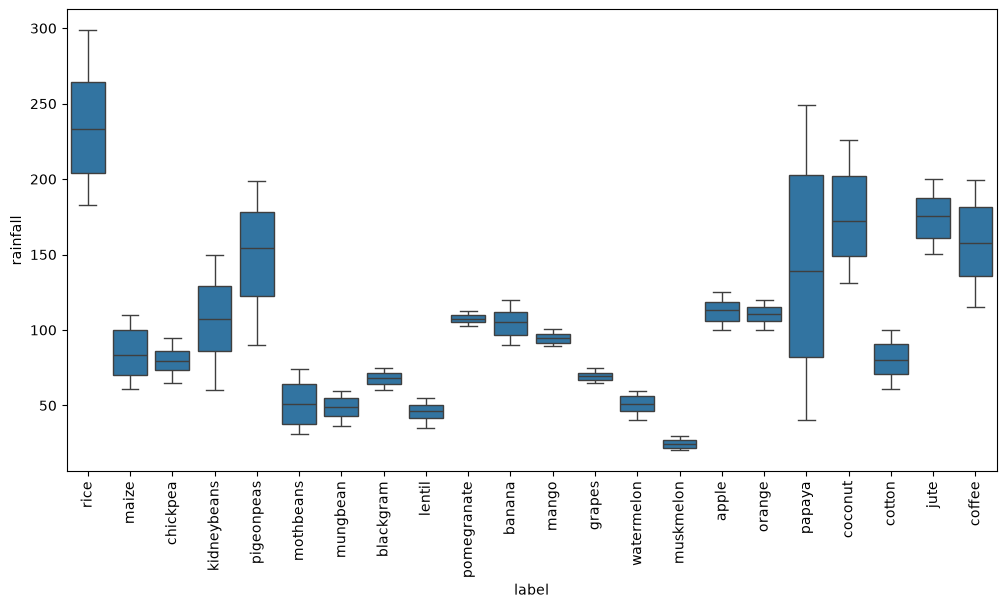

In [33]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df,
            x="label",
            y="rainfall")

plt.xticks(rotation=90)

plt.show()

## Outlier_Detection

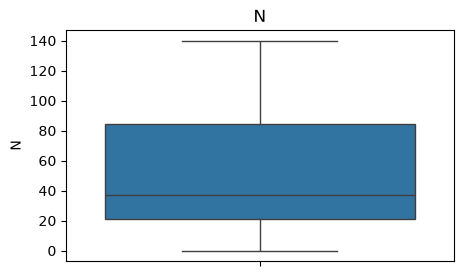

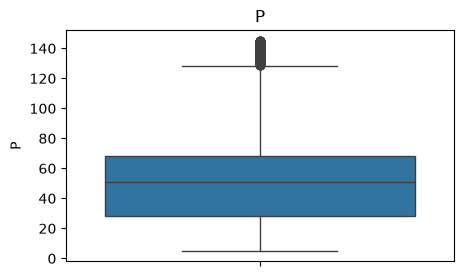

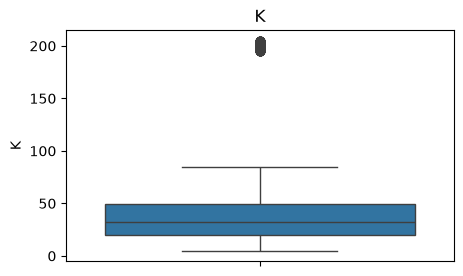

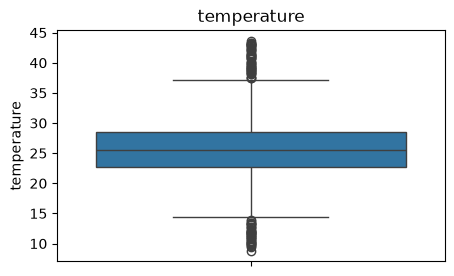

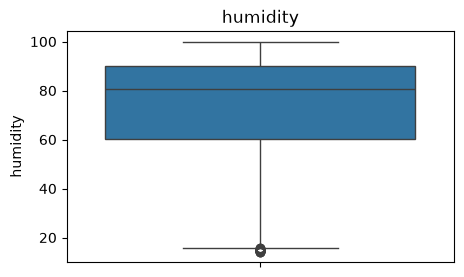

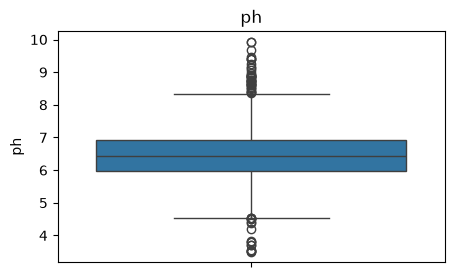

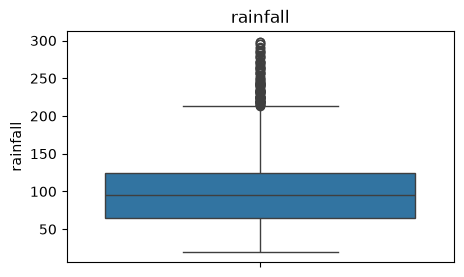

In [34]:
columns=df.columns[:-1]

for column in columns:

    plt.figure(figsize=(5,3))

    sns.boxplot(df[column])

    plt.title(column)

    plt.show()

# IQR Method

In [35]:
for column in columns:

    Q1=df[column].quantile(0.25)

    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    outliers=df[(df[column]<lower)|(df[column]>upper)]

    print(column," :",len(outliers))

N  : 0
P  : 138
K  : 200
temperature  : 86
humidity  : 30
ph  : 57
rainfall  : 100


## Feature Importance

In [36]:
from sklearn.ensemble import RandomForestClassifier

X=df.drop("label",axis=1)

y=df["label"]

model=RandomForestClassifier(random_state=42)

model.fit(X,y)

importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
6,rainfall,0.225676
4,humidity,0.215976
2,K,0.177675
1,P,0.152107
0,N,0.101705
3,temperature,0.073685
5,ph,0.053175


# data preprocessing

In [37]:
from sklearn.preprocessing import LabelEncoder

label_encoder=LabelEncoder()

df["label"]=label_encoder.fit_transform(df["label"])

In [38]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,20
1,85,58,41,21.770462,80.319644,7.038096,226.655537,20
2,60,55,44,23.004459,82.320763,7.840207,263.964248,20
3,74,35,40,26.491096,80.158363,6.980401,242.864034,20
4,78,42,42,20.130175,81.604873,7.628473,262.717340,20


In [45]:
y

0       20
1       20
2       20
3       20
4       20
        ..
2195     5
2196     5
2197     5
2198     5
2199     5
Name: label, Length: 2200, dtype: int64

In [46]:
import os

In [47]:
processed_data_path = "../Data/processed"

os.makedirs(processed_data_path, exist_ok=True)


In [48]:
output_file = os.path.join(
    processed_data_path,
    "Crop_recommendation_processed.csv"
)

df.to_csv(output_file, index=False)